##### Confusion Matrix: a square matrix reporting the counts of the True Positive (TP), True Negative (TN), False Positive (FP) and False Negative (FN)
<img src="images/confusion_matrix.png" width=300>

In [14]:
import numpy as np
from sklearn.svm import SVC
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [8]:
# get data
dataset = load_breast_cancer()
X = dataset.data
y = dataset.target
labels = dataset.target_names
print(labels)
print(np.unique(y))

['malignant' 'benign']
[0 1]


In [9]:
# split data
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, shuffle=True, random_state=1, test_size=0.2)

In [10]:
# pipeline
pipe_svc = make_pipeline(StandardScaler(),
                         SVC())

In [11]:
# train model and predict
pipe_svc.fit(X_train, y_train)
y_pred = pipe_svc.predict(X_test)

[[40  2]
 [ 0 72]]


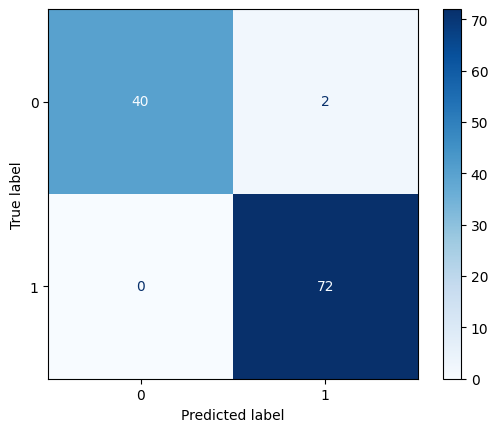

In [28]:
# confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true=y_test, y_pred=y_pred) #, normalize='true'
print(cm)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues")
plt.show()

**- True Postive Rate vs False Negative Rate:** (TP/all Postive labels vs FN/all Negative labels)

<img src="images/fpr_tpr.png" width=300>

**- Precision (PRE) vs Recall (REC) ~ TPR**

<img src="images/pre.png" width=250> \
<img src="images/rec.png" width=350>

**F1 score:**

<img src="images/f1.png" width=300>

In [30]:
from sklearn.metrics import precision_score, recall_score, f1_score
precision = precision_score(y_true=y_test, y_pred=y_pred)
recall = recall_score(y_true=y_test, y_pred=y_pred)
f1 = f1_score(y_true=y_test, y_pred=y_pred)
print(f"{precision=}")
print(f"{recall=}")
print(f"{f1=}")

precision=0.972972972972973
recall=1.0
f1=0.9863013698630136


##### Plotting a Receiver Operating Characteristic (ROC)
- ROC is useful to select models for classification based on TPR and FPR
- The diagonal of ROC can be interpreted as random guessing.
- Based on ROC, we can compute ROC area under the curve (ROC AUC) to characterize the performance of a classification model

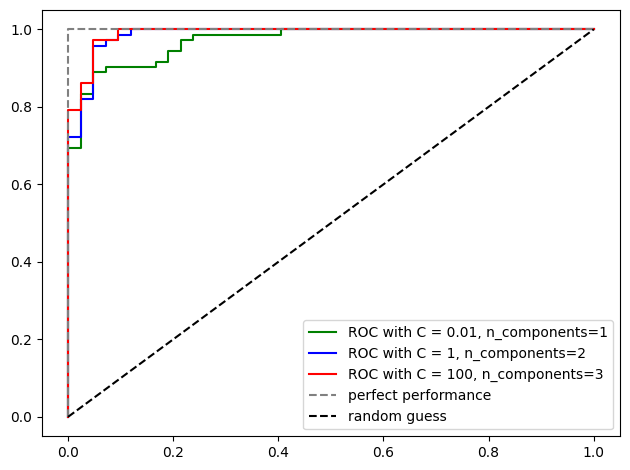

In [74]:
from sklearn.decomposition import PCA
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LogisticRegression

C_params = [0.01, 1, 100]
colors = ['g', 'b', 'r']
roc_aucs = []
for idx, c in enumerate(C_params):
    pipe = make_pipeline(StandardScaler(),
                         PCA(n_components=idx + 1),
                         LogisticRegression(C=c))
    pipe.fit(X_train, y_train)
    y_pred_probas = pipe.predict_proba(X_test)
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_probas[:, 1], pos_label=1)
    roc_auc = auc(fpr, tpr)
    roc_aucs.append(roc_auc)
    plt.plot(fpr, tpr, label=f"ROC with C = {c}, n_components={idx+1}", color=colors[idx])

plt.plot([0., 0., 1.], [0., 1., 1.], linestyle='--', color="gray", label="perfect performance")
plt.plot([0., 1.], [0., 1.], linestyle='--', color="black", label="random guess")

plt.legend()
plt.tight_layout()
plt.show()

In [70]:
print(roc_aucs)

[0.970568783068783, 0.9871031746031745, 0.9904100529100529]


**Scoring metrics for multiclass classification**
- For strategy: OvA: one-versus-all
- Micro: from individual TP and FP

<img src='images/micro.png' width=350>

- Macro: from averages score of different systems

<img src='images/macro.png' width=350>

##### Class imbalance

In [108]:
print(np.bincount(y_train))
print(np.bincount(y_test))

[170 285]
[42 72]


In [127]:
X_test_imbalanced = np.vstack((X_test[y_test==0][:42], X_test[y_test==1][:14]))
y_test_imbalanced = np.hstack((y_test[y_test==0][:42], y_test[y_test==1][:14]))

X_test_equal = np.vstack((X_test[y_test==0][:40], X_test[y_test==1][:40]))
y_test_equal= np.hstack((y_test[y_test==0][:40], y_test[y_test==1][:40]))

In [151]:
# imbalance dataset training -> score on the test set
X_train_imbalanced = np.vstack((X_train[y_train==0][:150], X_train[y_train==1][:50]))
y_train_imbalanced = np.hstack((y_train[y_train==0][:150], y_train[y_train==1][:50]))
pipe_svc.fit(X_train_imbalanced, y_train_imbalanced)
print(pipe_svc.score(X_test, y_test))
print("same imbalanced distro: ", pipe_svc.score(X_test_imbalanced, y_test_imbalanced))
print("equal distro: ", pipe_svc.score(X_test_equal, y_test_equal))

0.9473684210526315
same imbalanced distro:  0.9821428571428571
equal distro:  0.9375


In [158]:
# downsampling
X_train_equal = np.vstack((X_train[y_train==0][:100], X_train[y_train==1][:100]))
y_train_equal = np.hstack((y_train[y_train==0][:100], y_train[y_train==1][:100]))
np.bincount(y_train_imbalanced)

pipe_svc.fit(X_train_equal, y_train_equal)
print(pipe_svc.score(X_test, y_test))
print("imbalanced distro: ", pipe_svc.score(X_test_imbalanced, y_test_imbalanced))
print("same equal distro: ", pipe_svc.score(X_test_equal, y_test_equal))

0.9824561403508771
imbalanced distro:  0.9642857142857143
same equal distro:  0.975


In [157]:
# upsampling
from sklearn.utils import resample
X_train_upsampled, y_train_upsampled = resample(X_train[y_train==0], y_train[y_train==0], replace=True,
                                                  n_samples=X_train[y_train==1].shape[0], random_state=8)

In [154]:
print(X_train_upsampled.shape)

(285, 30)


In [155]:
X_train_balanced = np.vstack((X_train[y_train==1], X_train_upsampled))
y_train_balanced = np.hstack((y_train[y_train==1], y_train_upsampled))
np.bincount(y_train_balanced)

array([285, 285])

In [156]:
pipe_svc.fit(X_train_balanced, y_train_balanced)
print(pipe_svc.score(X_test, y_test))
print("imbalanced distro: ", pipe_svc.score(X_test_imbalanced, y_test_imbalanced))
print("equal distro: ", pipe_svc.score(X_test_equal, y_test_equal))

0.9736842105263158
imbalanced distro:  0.9642857142857143
equal distro:  0.9625
